In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'E:\project_DS\COVID-19 Virus\tested_worldwide.csv')

df.head(10)

,Date,Country_Region,Province_State,positive,active,hospitalized,hospitalizedCurr,recovered,death,total_tested,daily_tested,daily_positive
0,2020-01-16,Iceland,All States,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-17,Iceland,All States,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,2020-01-18,Iceland,All States,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
3,2020-01-20,South Korea,All States,1.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN
4,2020-01-22,United States,All States,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
5,2020-01-22,United States,Massachusetts,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
6,2020-01-22,United States,Washington,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
7,2020-01-23,United States,All States,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
8,2020-01-23,United States,Massachusetts,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
9,2020-01-23,United States,Washington,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0


In [3]:
df.isnull().sum()

Date                    0
Country_Region          0
Province_State          0
positive             4242
active               9833
hospitalized        19231
hospitalizedCurr    13080
recovered            9626
death                4010
total_tested          912
daily_tested         1174
daily_positive       4557
dtype: int64

In [4]:
df.shape

(27641, 12)

In [7]:

# Check column data types
df.info()

# Check data types in a compact table
print(df.dtypes)

# Check the number of duplicated rows
print("Duplicated rows:", df.duplicated().sum())

# Check the date range
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())

# Check the number of countries and regions
print("Countries:", df["Country_Region"].nunique())
print("Regions:", df["Province_State"].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27641 entries, 0 to 27640
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              27641 non-null  object 
 1   Country_Region    27641 non-null  object 
 2   Province_State    27641 non-null  object 
 3   positive          23399 non-null  float64
 4   active            17808 non-null  float64
 5   hospitalized      8410 non-null   float64
 6   hospitalizedCurr  14561 non-null  float64
 7   recovered         18015 non-null  float64
 8   death             23631 non-null  float64
 9   total_tested      26729 non-null  float64
 10  daily_tested      26467 non-null  float64
 11  daily_positive    23084 non-null  float64
dtypes: float64(9), object(3)
memory usage: 2.5+ MB
Date                 object
Country_Region       object
Province_State       object
positive            float64
active              float64
hospitalized        float64
hospitalizedC

In [8]:

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [11]:

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": ((df.isnull().sum() / len(df)) * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

display(missing_summary)

,Missing Values,Missing Percentage
hospitalized,19231,69.57
hospitalizedCurr,13080,47.32
active,9833,35.57
recovered,9626,34.83
daily_positive,4557,16.49
positive,4242,15.35
death,4010,14.51
daily_tested,1174,4.25
total_tested,912,3.30
Date,0,0.00


In [12]:

# Inspect the different types of regional records
print(df["Province_State"].value_counts().head(15))

# Inspect records for the United States
display(
    df.loc[
        df["Country_Region"].eq("United States"),
        ["Date", "Country_Region", "Province_State",
         "positive", "total_tested"]
    ].head(15)
)

Province_State
All States                      7881
Washington                       291
Massachusetts                    291
South Australia                  290
Victoria                         290
Tasmania                         290
Western Australia                290
Queensland                       290
Northern Territory               290
New South Wales                  290
Australian Capital Territory     290
Florida                          284
New Jersey                       272
Nebraska                         267
British Columbia                 258
Name: count, dtype: int64


,Date,Country_Region,Province_State,positive,total_tested
4,2020-01-22,United States,All States,0.0,0.0
5,2020-01-22,United States,Massachusetts,0.0,0.0
6,2020-01-22,United States,Washington,0.0,0.0
7,2020-01-23,United States,All States,0.0,0.0
8,2020-01-23,United States,Massachusetts,0.0,0.0
9,2020-01-23,United States,Washington,0.0,0.0
11,2020-01-24,United States,All States,0.0,0.0
12,2020-01-24,United States,Massachusetts,0.0,0.0
13,2020-01-24,United States,Washington,0.0,0.0
24,2020-01-25,United States,All States,0.0,0.0


In [13]:

# Keep only country-level records
covid_df_all_states = df.loc[
    df["Province_State"] == "All States"
].copy()

# Remove the province/state column
covid_df_all_states = covid_df_all_states.drop(
    columns=["Province_State"]
)

# Check the new dataset
print("Shape:", covid_df_all_states.shape)
display(covid_df_all_states.head())

Shape: (7881, 11)


,Date,Country_Region,positive,active,hospitalized,hospitalizedCurr,recovered,death,total_tested,daily_tested,daily_positive
0,2020-01-16,Iceland,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-17,Iceland,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,2020-01-18,Iceland,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
3,2020-01-20,South Korea,1.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN
4,2020-01-22,United States,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN


In [14]:

covid_df_all_states_daily = covid_df_all_states[
    [
        "Date",
        "Country_Region",
        "active",
        "hospitalizedCurr",
        "daily_tested",
        "daily_positive"
    ]
].copy()

display(covid_df_all_states_daily.head())

,Date,Country_Region,active,hospitalizedCurr,daily_tested,daily_positive
0,2020-01-16,Iceland,NaN,NaN,NaN,NaN
1,2020-01-17,Iceland,NaN,NaN,NaN,1.0
2,2020-01-18,Iceland,NaN,NaN,NaN,3.0
3,2020-01-20,South Korea,NaN,NaN,NaN,NaN
4,2020-01-22,United States,NaN,NaN,NaN,NaN


In [15]:

# Filter country-level records
covid_df_all_states = df.loc[
    df["Province_State"].eq("All States")
].copy()

print("Filtered dataset shape:", covid_df_all_states.shape)

# Check the first rows
display(
    covid_df_all_states[
        ["Date", "Country_Region", "Province_State",
         "positive", "total_tested"]
    ].head()
)

# Verify that only All States records remain
print(
    "Unique region values:",
    covid_df_all_states["Province_State"].unique()
)

Filtered dataset shape: (7881, 12)


,Date,Country_Region,Province_State,positive,total_tested
0,2020-01-16,Iceland,All States,3.0,NaN
1,2020-01-17,Iceland,All States,4.0,NaN
2,2020-01-18,Iceland,All States,7.0,NaN
3,2020-01-20,South Korea,All States,1.0,4.0
4,2020-01-22,United States,All States,0.0,0.0


Unique region values: ['All States']


In [16]:

# Keep country-level records only
covid_df_all_states = df.loc[
    df["Province_State"].eq("All States")
].copy()

# Sort records by date
covid_df_all_states = covid_df_all_states.sort_values("Date")

# Keep the latest available record for each country
latest_country_data = (
    covid_df_all_states
    .dropna(subset=["positive"])
    .groupby("Country_Region", as_index=False)
    .tail(1)
)

# Select the relevant columns and rank countries
top_10_countries = (
    latest_country_data[
        ["Country_Region", "Date", "positive", "total_tested"]
    ]
    .sort_values("positive", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(top_10_countries)

,Country_Region,Date,positive,total_tested
0,United States,2020-11-07,9761481.0,136620652.0
1,Italy,2020-11-08,935104.0,17374713.0
2,Russia,2020-06-03,432277.0,11426045.0
3,Bangladesh,2020-11-08,420238.0,2442602.0
4,Czechia,2020-11-07,411220.0,NaN
5,Canada,2020-11-07,260055.0,9884582.0
6,Turkey,2020-07-21,221500.0,4359657.0
7,Spain,2020-04-30,215216.0,1932455.0
8,United Kingdom,2020-05-11,163418.0,1400107.0
9,Germany,2020-04-27,157641.0,2547052.0


In [17]:

# Keep country-level records
country_data = df.loc[
    df["Province_State"].eq("All States")
].copy()

# Ensure Date is datetime
country_data["Date"] = pd.to_datetime(
    country_data["Date"], errors="coerce"
)

# Keep records with both values available
valid_data = country_data.dropna(
    subset=["positive", "total_tested"]
).copy()

# Avoid division by zero
valid_data = valid_data.loc[
    valid_data["total_tested"] > 0
]

# Get the latest valid record for each country
latest_valid = (
    valid_data.sort_values("Date")
    .groupby("Country_Region")
    .tail(1)
    .copy()
)

# Calculate positive rate
latest_valid["positive_rate"] = (
    latest_valid["positive"]
    / latest_valid["total_tested"]
    * 100
)

# Rank countries by positive rate
top_positive_rate = latest_valid.sort_values(
    "positive_rate", ascending=False
).head(10)

display(
    top_positive_rate[
        [
            "Country_Region",
            "Date",
            "positive",
            "total_tested",
            "positive_rate"
        ]
    ].reset_index(drop=True)
)

,Country_Region,Date,positive,total_tested,positive_rate
0,Tanzania,2020-05-09,509.0,652.0,78.067485
1,Burkina Faso,2020-04-29,641.0,1333.0,48.087022
2,Ecuador,2020-04-30,24934.0,69054.0,36.107973
3,Costa Rica,2020-11-06,115417.0,329416.0,35.036853
4,Mexico,2020-05-10,35022.0,110977.0,31.557890
5,Democratic Republic of the Congo,2020-04-30,500.0,1733.0,28.851702
6,DR Congo,2020-04-30,500.0,1733.0,28.851702
7,Lombardy,2020-04-16,63094.0,232674.0,27.116910
8,Armenia,2020-11-07,106424.0,438855.0,24.250379
9,Guinea,2020-04-30,1495.0,6207.0,24.085710


In [18]:

# Inspect the original records for suspicious names
check_names = [
    "Tanzania",
    "Burkina Faso",
    "Democratic Republic of the Congo",
    "DR Congo",
    "Lombardy"
]

display(
    df.loc[
        df["Country_Region"].isin(check_names),
        [
            "Date",
            "Country_Region",
            "Province_State",
            "positive",
            "total_tested"
        ]
    ].sort_values(["Country_Region", "Date"])
)

,Date,Country_Region,Province_State,positive,total_tested
7086,2020-04-29,Burkina Faso,All States,641.0,1333.0
7863,2020-05-05,Burkina Faso,All States,NaN,1333.0
9830,2020-05-21,Burkina Faso,All States,NaN,6642.0
17143,2020-07-29,Burkina Faso,All States,NaN,17400.0
7234,2020-04-30,DR Congo,All States,500.0,1733.0
7883,2020-05-05,DR Congo,All States,NaN,2256.0
11214,2020-06-02,DR Congo,All States,NaN,9508.0
17052,2020-07-28,DR Congo,All States,NaN,44051.0
24059,2020-10-05,DR Congo,All States,NaN,61151.0
6978,2020-04-28,Democratic Republic of the Congo,All States,471.0,1495.0


In [19]:

# Start with country-level records
country_data = df.loc[
    df["Province_State"].eq("All States")
].copy()

country_data["Date"] = pd.to_datetime(
    country_data["Date"], errors="coerce"
)

# Standardize country names
country_data["Country_Region"] = (
    country_data["Country_Region"].replace({
        "DR Congo": "Democratic Republic of the Congo"
    })
)

# Exclude the regional entry
country_data = country_data.loc[
    country_data["Country_Region"].ne("Lombardy")
].copy()

# Keep valid observations for calculating positive rates
valid_data = country_data.dropna(
    subset=["positive", "total_tested"]
).copy()

valid_data = valid_data.loc[
    valid_data["total_tested"] > 0
]

# Get the latest valid observation per country
latest_valid = (
    valid_data.sort_values("Date")
    .groupby("Country_Region")
    .tail(1)
    .copy()
)

# Calculate positive rate
latest_valid["positive_rate"] = (
    latest_valid["positive"]
    / latest_valid["total_tested"]
    * 100
)

# Display the top 10 countries
top_10_positive_rate = (
    latest_valid
    .sort_values("positive_rate", ascending=False)
    .head(10)
    [[
        "Country_Region",
        "Date",
        "positive",
        "total_tested",
        "positive_rate"
    ]]
    .reset_index(drop=True)
)

display(top_10_positive_rate)

,Country_Region,Date,positive,total_tested,positive_rate
0,Tanzania,2020-05-09,509.0,652.0,78.067485
1,Burkina Faso,2020-04-29,641.0,1333.0,48.087022
2,Ecuador,2020-04-30,24934.0,69054.0,36.107973
3,Costa Rica,2020-11-06,115417.0,329416.0,35.036853
4,Mexico,2020-05-10,35022.0,110977.0,31.557890
5,Democratic Republic of the Congo,2020-04-30,500.0,1733.0,28.851702
6,Armenia,2020-11-07,106424.0,438855.0,24.250379
7,Guinea,2020-04-30,1495.0,6207.0,24.085710
8,Piedmont,2020-04-16,19108.0,80708.0,23.675472
9,Cameroon,2020-05-05,2104.0,9254.0,22.736114


In [20]:

country_names = sorted(
    df.loc[
        df["Province_State"].eq("All States"),
        "Country_Region"
    ].dropna().unique()
)

for country in country_names:
    print(country)

Afghanistan
Albania
Algeria
Argentina
Armenia
Australia
Austria
Azerbaijan
Bahrain
Bangladesh
Barbados
Belarus
Belgium
Bhutan
Bolivia
Bosnia and Herzegovina
Brazil
Bulgaria
Burkina Faso
Cameroon
Canada
Chile
Colombia
Costa Rica
Croatia
Cuba
Cyprus
Czech Republic
Czechia
DR Congo
Democratic Republic of the Congo
Denmark
Dominican Republic
Ecuador
Egypt
El Salvador
Emilia-Romagna
Estonia
Ethiopia
Faroe Islands
Fiji
Finland
France
Gabon
Germany
Ghana
Greece
Greenland
Grenada
Guatemala
Guinea
Honduras
Hungary
Iceland
India
Indonesia
Iran
Iraq
Ireland
Israel
Italy
Ivory Coast
Jamaica
Japan
Jordan
Kazakhstan
Kenya
Kosovo
Kuwait
Kyrgyzstan
Latvia
Lebanon
Libya
Liguria
Lithuania
Lombardy
Luxembourg
Madagascar
Malawi
Malaysia
Maldives
Malta
Marche
Mauritius
Mexico
Montenegro
Morocco
Mozambique
Myanmar
Namibia
Nepal
Netherlands
New Zealand
Nigeria
North Korea
North Macedonia
Northern Cyprus
Norway
Oman
Pakistan
Palestine
Panama
Papua New Guinea
Paraguay
Peru
Philippines
Piedmont
Poland
Portugal


In [21]:

# Create a clean copy of country-level records
country_data = df.loc[
    df["Province_State"].eq("All States")
].copy()

country_data["Date"] = pd.to_datetime(
    country_data["Date"], errors="coerce"
)

# Standardize known country-name variants
country_data["Country_Region"] = (
    country_data["Country_Region"].replace({
        "DR Congo": "Democratic Republic of the Congo",
        "Czech Republic": "Czechia"
    })
)

# Exclude known Italian regions and Scotland
regional_entries = [
    "Emilia-Romagna",
    "Liguria",
    "Lombardy",
    "Marche",
    "Piedmont",
    "Tuscany",
    "Veneto",
    "Scotland"
]

country_data = country_data.loc[
    ~country_data["Country_Region"].isin(regional_entries)
].copy()

# Check the result
print("Rows after cleaning:", len(country_data))
print(
    "Unique reported names:",
    country_data["Country_Region"].nunique()
)

display(
    country_data[
        ["Date", "Country_Region", "positive", "total_tested"]
    ].head()
)

Rows after cleaning: 7808
Unique reported names: 136


,Date,Country_Region,positive,total_tested
0,2020-01-16,Iceland,3.0,NaN
1,2020-01-17,Iceland,4.0,NaN
2,2020-01-18,Iceland,7.0,NaN
3,2020-01-20,South Korea,1.0,4.0
4,2020-01-22,United States,0.0,0.0


In [22]:

# Check duplicate country-date combinations
duplicate_country_dates = country_data.duplicated(
    subset=["Country_Region", "Date"],
    keep=False
)

print(
    "Rows involved in duplicate country-date pairs:",
    duplicate_country_dates.sum()
)

# Inspect any duplicates
display(
    country_data.loc[
        duplicate_country_dates,
        ["Date", "Country_Region", "positive", "total_tested"]
    ].sort_values(["Country_Region", "Date"]).head(20)
)

# Check missing values in the key analysis columns
print(
    country_data[
        ["positive", "total_tested"]
    ].isnull().sum()
)

Rows involved in duplicate country-date pairs: 12


,Date,Country_Region,positive,total_tested
7104,2020-04-29,Czechia,7581.0,242088.0
7105,2020-04-29,Czechia,7592.0,246475.0
7493,2020-05-02,Czechia,7740.0,253826.0
7494,2020-05-02,Czechia,7768.0,262253.0
7234,2020-04-30,Democratic Republic of the Congo,500.0,1733.0
7235,2020-04-30,Democratic Republic of the Congo,500.0,1733.0
4214,2020-04-06,United States,363220.0,1961953.0
4215,2020-04-06,United States,733840.0,3923139.0
4352,2020-04-07,United States,395784.0,2096564.0
4353,2020-04-07,United States,797025.0,4212095.0


positive        2166
total_tested     468
dtype: int64


In [23]:

# Inspect all columns for the duplicated country-date records
duplicate_details = country_data.loc[
    country_data.duplicated(
        subset=["Country_Region", "Date"],
        keep=False
    )
].sort_values(["Country_Region", "Date"])

display(duplicate_details)

# Check how many are exact duplicate rows
print(
    "Exact duplicate rows:",
    country_data.duplicated().sum()
)

,Date,Country_Region,Province_State,positive,active,hospitalized,hospitalizedCurr,recovered,death,total_tested,daily_tested,daily_positive
7104,2020-04-29,Czechia,All States,7581.0,NaN,NaN,NaN,NaN,NaN,242088.0,NaN,NaN
7105,2020-04-29,Czechia,All States,7592.0,NaN,NaN,NaN,NaN,NaN,246475.0,7322.0,75.0
7493,2020-05-02,Czechia,All States,7740.0,NaN,NaN,NaN,NaN,NaN,253826.0,3912.0,53.0
7494,2020-05-02,Czechia,All States,7768.0,NaN,NaN,NaN,NaN,NaN,262253.0,3885.0,18.0
7234,2020-04-30,Democratic Republic of the Congo,All States,500.0,NaN,NaN,NaN,NaN,NaN,1733.0,NaN,NaN
7235,2020-04-30,Democratic Republic of the Congo,All States,500.0,NaN,NaN,NaN,NaN,NaN,1733.0,119.0,14.0
4214,2020-04-06,United States,All States,363220.0,NaN,NaN,NaN,NaN,NaN,1961953.0,NaN,NaN
4215,2020-04-06,United States,All States,733840.0,NaN,NaN,NaN,NaN,NaN,3923139.0,NaN,NaN
4352,2020-04-07,United States,All States,395784.0,NaN,NaN,NaN,NaN,NaN,2096564.0,134611.0,32564.0
4353,2020-04-07,United States,All States,797025.0,NaN,NaN,NaN,NaN,NaN,4212095.0,288956.0,63185.0


Exact duplicate rows: 0


In [24]:

us_check = df.loc[
    (df["Country_Region"] == "United States")
    & (pd.to_datetime(df["Date"], errors="coerce").dt.strftime("%Y-%m-%d").isin([
        "2020-04-06",
        "2020-04-07",
        "2020-04-08"
    ]))
].copy()

display(
    us_check[
        ["Date", "Country_Region", "Province_State",
         "positive", "total_tested", "daily_tested", "daily_positive"]
    ].sort_values(["Date", "positive"])
)

,Date,Country_Region,Province_State,positive,total_tested,daily_tested,daily_positive
4216,2020-04-06,United States,American Samoa,0.0,3.0,0.0,0.0
4251,2020-04-06,United States,Northern Mariana Islands,8.0,21.0,0.0,0.0
4264,2020-04-06,United States,Virgin Islands,43.0,265.0,17.0,1.0
4226,2020-04-06,United States,Guam,113.0,618.0,13.0,1.0
4213,2020-04-06,United States,Alaska,191.0,6883.0,599.0,6.0
...,...,...,...,...,...,...,...
4506,2020-04-08,United States,Michigan,28064.0,81240.0,3932.0,1100.0
4514,2020-04-08,United States,New Jersey,47437.0,100416.0,5442.0,3021.0
4516,2020-04-08,United States,New York,149316.0,365153.0,25095.0,10453.0
4482,2020-04-08,United States,All States,423164.0,2206994.0,110430.0,27380.0


In [25]:

# Keep rows with valid values for the positivity-rate calculation
valid_pairs = country_data.dropna(
    subset=["positive", "total_tested"]
).copy()

valid_pairs = valid_pairs.loc[
    valid_pairs["total_tested"] > 0
].copy()

# Find the latest date with valid data for each country
latest_dates = valid_pairs.groupby(
    "Country_Region"
)["Date"].transform("max")

latest_candidates = valid_pairs.loc[
    valid_pairs["Date"].eq(latest_dates)
].copy()

# Check whether any country has multiple records on its latest valid date
latest_duplicates = latest_candidates.loc[
    latest_candidates.duplicated(
        subset=["Country_Region", "Date"],
        keep=False
    )
].sort_values(["Country_Region", "Date"])

print("Countries with conflicting or repeated latest records:")
display(
    latest_duplicates[
        ["Date", "Country_Region", "positive", "total_tested",
         "daily_tested", "daily_positive"]
    ]
)

print("Number of rows to inspect:", len(latest_duplicates))

Countries with conflicting or repeated latest records:


,Date,Country_Region,positive,total_tested,daily_tested,daily_positive
7234,2020-04-30,Democratic Republic of the Congo,500.0,1733.0,NaN,NaN
7235,2020-04-30,Democratic Republic of the Congo,500.0,1733.0,119.0,14.0


Number of rows to inspect: 2


In [26]:

# Prefer the more complete row when country and date are identical
country_data_clean = (
    country_data
    .sort_values(
        ["Country_Region", "Date"],
        na_position="first"
    )
    .drop_duplicates(
        subset=["Country_Region", "Date"],
        keep="last"
    )
    .copy()
)

# Keep records with valid positive cases and total tests
valid_pairs = country_data_clean.dropna(
    subset=["positive", "total_tested"]
).copy()

valid_pairs = valid_pairs.loc[
    valid_pairs["total_tested"] > 0
].copy()

# Select the latest valid record for each country
latest_valid = (
    valid_pairs
    .sort_values(["Country_Region", "Date"])
    .groupby("Country_Region")
    .tail(1)
    .copy()
)

# Calculate positivity rate
latest_valid["positivity_rate"] = (
    latest_valid["positive"]
    / latest_valid["total_tested"]
    * 100
)

# Show the 10 countries with the highest rates
top_10 = latest_valid.sort_values(
    "positivity_rate",
    ascending=False
).head(10)

display(
    top_10[
        ["Country_Region", "Date", "positive",
         "total_tested", "positivity_rate"]
    ].round({"positivity_rate": 2})
)

,Country_Region,Date,positive,total_tested,positivity_rate
8438,Tanzania,2020-05-09,509.0,652.0,78.07
7086,Burkina Faso,2020-04-29,641.0,1333.0,48.09
7237,Ecuador,2020-04-30,24934.0,69054.0,36.11
27433,Costa Rica,2020-11-06,115417.0,329416.0,35.04
8557,Mexico,2020-05-10,35022.0,110977.0,31.56
7235,Democratic Republic of the Congo,2020-04-30,500.0,1733.0,28.85
27519,Armenia,2020-11-07,106424.0,438855.0,24.25
7242,Guinea,2020-04-30,1495.0,6207.0,24.09
7864,Cameroon,2020-05-05,2104.0,9254.0,22.74
6618,Panama,2020-04-25,5338.0,24304.0,21.96


In [27]:

# Compare the latest available dates for each country
date_check = country_data_clean.groupby("Country_Region").agg(
    latest_any_date=("Date", "max")
).reset_index()

latest_positive_date = (
    country_data_clean.dropna(subset=["positive"])
    .groupby("Country_Region")["Date"]
    .max()
    .rename("latest_positive_date")
)

latest_tests_date = (
    country_data_clean.dropna(subset=["total_tested"])
    .groupby("Country_Region")["Date"]
    .max()
    .rename("latest_tests_date")
)

latest_both_date = (
    valid_pairs.groupby("Country_Region")["Date"]
    .max()
    .rename("latest_both_date")
)

date_check = (
    date_check
    .merge(latest_positive_date, on="Country_Region", how="left")
    .merge(latest_tests_date, on="Country_Region", how="left")
    .merge(latest_both_date, on="Country_Region", how="left")
)

date_check["days_since_latest_record"] = (
    date_check["latest_any_date"] - date_check["latest_both_date"]
).dt.days

# Inspect the countries currently ranked in the top 10
top10_date_check = (
    top_10[["Country_Region", "positivity_rate"]]
    .merge(date_check, on="Country_Region", how="left")
    .sort_values("positivity_rate", ascending=False)
)

display(top10_date_check)

,Country_Region,positivity_rate,latest_any_date,latest_positive_date,latest_tests_date,latest_both_date,days_since_latest_record
0,Tanzania,78.067485,2020-06-06,2020-05-09,2020-06-06,2020-05-09,28.0
1,Burkina Faso,48.087022,2020-07-29,2020-04-29,2020-07-29,2020-04-29,91.0
2,Ecuador,36.107973,2020-11-06,2020-04-30,2020-11-06,2020-04-30,190.0
3,Costa Rica,35.036853,2020-11-07,2020-11-07,2020-11-06,2020-11-06,1.0
4,Mexico,31.557890,2020-10-31,2020-05-10,2020-10-31,2020-05-10,174.0
5,Democratic Republic of the Congo,28.851702,2020-10-05,2020-04-30,2020-10-05,2020-04-30,158.0
6,Armenia,24.250379,2020-11-07,2020-11-07,2020-11-07,2020-11-07,0.0
7,Guinea,24.085710,2020-11-05,2020-04-30,2020-11-05,2020-04-30,189.0
8,Cameroon,22.736114,2020-07-16,2020-05-05,2020-07-16,2020-05-05,72.0
9,Panama,21.963463,2020-11-06,2020-04-25,2020-11-06,2020-04-25,195.0


In [28]:

# Calculate the latest valid positivity rate for every country
latest_valid = (
    valid_pairs
    .sort_values(["Country_Region", "Date"])
    .groupby("Country_Region")
    .tail(1)
    .copy()
)

latest_valid["positivity_rate"] = (
    latest_valid["positive"] / latest_valid["total_tested"] * 100
)

# Add the date-gap information
ranked_countries = latest_valid.merge(
    date_check[
        ["Country_Region", "latest_any_date", "days_since_latest_record"]
    ],
    on="Country_Region",
    how="left"
)

# Keep countries whose latest valid record is within 7 days
recent_countries = ranked_countries.loc[
    ranked_countries["days_since_latest_record"].le(7)
].copy()

recent_countries = recent_countries.sort_values(
    "positivity_rate", ascending=False
)

print("Countries meeting the 7-day rule:", len(recent_countries))

display(
    recent_countries[
        ["Country_Region", "Date", "latest_any_date",
         "days_since_latest_record", "positive",
         "total_tested", "positivity_rate"]
    ].head(10).round({"positivity_rate": 2})
)

Countries meeting the 7-day rule: 23


,Country_Region,Date,latest_any_date,days_since_latest_record,positive,total_tested,positivity_rate
19,Costa Rica,2020-11-06,2020-11-07,1.0,115417.0,329416.0,35.04
2,Armenia,2020-11-07,2020-11-07,0.0,106424.0,438855.0,24.25
6,Bangladesh,2020-11-08,2020-11-08,0.0,420238.0,2442602.0,17.20
23,Czechia,2020-11-06,2020-11-07,1.0,403498.0,2557244.0,15.78
100,United Kingdom,2020-05-11,2020-05-13,2.0,163418.0,1400107.0,11.67
9,Belgium,2020-05-12,2020-05-13,1.0,54226.0,508697.0,10.66
84,Slovakia,2020-11-07,2020-11-07,0.0,75495.0,901327.0,8.38
101,United States,2020-11-07,2020-11-07,0.0,9761481.0,136620652.0,7.14
98,Ukraine,2020-05-31,2020-05-31,0.0,23672.0,356565.0,6.64
43,Italy,2020-11-08,2020-11-08,0.0,935104.0,17374713.0,5.38


In [29]:
# Define a recent common time window
end_date = country_data_clean["Date"].max()
start_date = end_date - pd.Timedelta(days=7)

print("Analysis window:", start_date.date(), "to", end_date.date())

# Keep valid records inside the common window
recent_valid_pairs = valid_pairs.loc[
    valid_pairs["Date"].between(start_date, end_date)
].copy()

# Select the latest valid record per country within this window
recent_ranking = (
    recent_valid_pairs
    .sort_values(["Country_Region", "Date"])
    .groupby("Country_Region")
    .tail(1)
    .copy()
)

# Calculate positivity rate
recent_ranking["positivity_rate"] = (
    recent_ranking["positive"]
    / recent_ranking["total_tested"]
    * 100
)

recent_ranking = recent_ranking.sort_values(
    "positivity_rate",
    ascending=False
)

print("Countries included:", len(recent_ranking))

display(
    recent_ranking[
        ["Country_Region", "Date", "positive",
         "total_tested", "positivity_rate"]
    ].head(10).round({"positivity_rate": 2})
)

Analysis window: 2020-11-02 to 2020-11-09
Countries included: 14


,Country_Region,Date,positive,total_tested,positivity_rate
27433,Costa Rica,2020-11-06,115417.0,329416.0,35.04
27519,Armenia,2020-11-07,106424.0,438855.0,24.25
27627,Bangladesh,2020-11-08,420238.0,2442602.0,17.20
27434,Czechia,2020-11-06,403498.0,2557244.0,15.78
27559,Slovakia,2020-11-07,75495.0,901327.0,8.38
27563,United States,2020-11-07,9761481.0,136620652.0,7.14
27629,Italy,2020-11-08,935104.0,17374713.0,5.38
27631,Serbia,2020-11-08,62747.0,1421154.0,4.42
27551,Greece,2020-11-07,54809.0,1926544.0,2.84
27533,Canada,2020-11-07,260055.0,9884582.0,2.63


In [30]:

# Countries with any record in the analysis window
countries_with_records = country_data_clean.loc[
    country_data_clean["Date"].between(start_date, end_date),
    "Country_Region"
].nunique()

# Countries with valid positive cases and test counts
countries_with_valid_data = recent_valid_pairs[
    "Country_Region"
].nunique()

# Countries with records but no valid pair in the window
print("Countries with records:", countries_with_records)
print("Countries with valid data:", countries_with_valid_data)
print(
    "Countries without a valid pair:",
    countries_with_records - countries_with_valid_data
)

Countries with records: 97
Countries with valid data: 14
Countries without a valid pair: 83


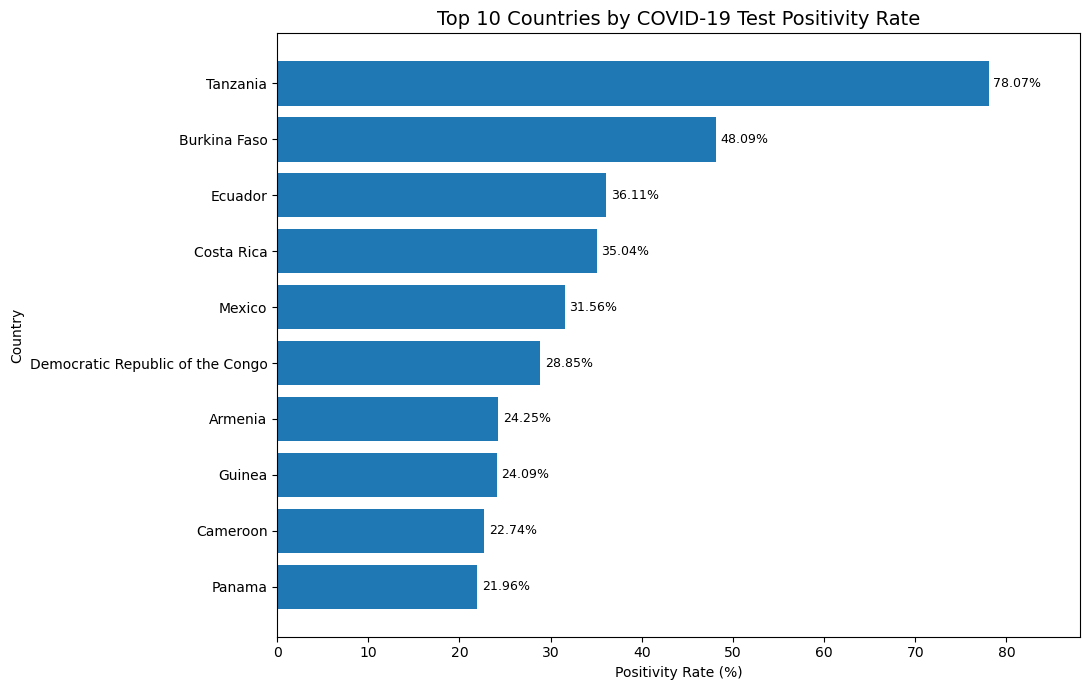

In [31]:
# Select the 10 countries with the highest positivity rates
top_10 = (
    latest_valid
    .sort_values("positivity_rate", ascending=False)
    .head(10)
    .sort_values("positivity_rate", ascending=True)
    .copy()
)

# Create the horizontal bar chart
plt.figure(figsize=(11, 7))

bars = plt.barh(
    top_10["Country_Region"],
    top_10["positivity_rate"]
)

# Add percentage labels
for bar, rate in zip(bars, top_10["positivity_rate"]):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.2f}%",
        va="center",
        fontsize=9
    )

plt.title(
    "Top 10 Countries by COVID-19 Test Positivity Rate",
    fontsize=14
)
plt.xlabel("Positivity Rate (%)")
plt.ylabel("Country")
plt.xlim(0, top_10["positivity_rate"].max() + 10)
plt.tight_layout()
plt.show()

In [32]:

top_10_table = (
    latest_valid
    .sort_values("positivity_rate", ascending=False)
    .head(10)
    .copy()
)

top_10_table["Date"] = top_10_table["Date"].dt.strftime("%Y-%m-%d")
top_10_table["positivity_rate"] = (
    top_10_table["positivity_rate"].round(2)
)

display(
    top_10_table[
        ["Country_Region", "Date", "positive",
         "total_tested", "positivity_rate"]
    ].rename(columns={
        "Country_Region": "Country",
        "positive": "Positive Cases",
        "total_tested": "Total Tests",
        "positivity_rate": "Positivity Rate (%)"
    })
)

,Country,Date,Positive Cases,Total Tests,Positivity Rate (%)
8438,Tanzania,2020-05-09,509.0,652.0,78.07
7086,Burkina Faso,2020-04-29,641.0,1333.0,48.09
7237,Ecuador,2020-04-30,24934.0,69054.0,36.11
27433,Costa Rica,2020-11-06,115417.0,329416.0,35.04
8557,Mexico,2020-05-10,35022.0,110977.0,31.56
7235,Democratic Republic of the Congo,2020-04-30,500.0,1733.0,28.85
27519,Armenia,2020-11-07,106424.0,438855.0,24.25
7242,Guinea,2020-04-30,1495.0,6207.0,24.09
7864,Cameroon,2020-05-05,2104.0,9254.0,22.74
6618,Panama,2020-04-25,5338.0,24304.0,21.96


### Findings

The analysis identifies the ten countries with the highest COVID-19 test positivity rates based on the latest available valid records for each country. Tanzania has the highest calculated rate, followed by Burkina Faso and Ecuador.

However, the records do not all come from the same date. Some countries have much older valid records than others, which limits the fairness of direct comparisons. Therefore, these results should be interpreted as an exploratory ranking of the available data, not as a definitive comparison of COVID-19 prevalence across countries.

The positivity rate is calculated as:

**Positivity Rate = (Positive Cases / Total Tests) × 100**
